## Evaluation matrics
- consistency
- accuracy
- distant targets prediction sensitivity
- Inspiration index: distance to substrate/product & connectivity 
- Advanced experimental reference：FCCg / FCCp

In [7]:
import pandas as pd
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(r'D:\code\github\strainOptimizer')
from strainOptimizer.analysis.dataset import calculate_exp_consistency,load_experiment_targets
import numpy as np
# from strainOptimizer.analysis.network import calculate_genetic_target_distance
# from strainOptimizer.analysis.FCC import calculate_FCC_by_abundance
# from strainOptimizer.io import load_model
import json

# set work dir
os.chdir(r'D:\code\github\strainOptimizer')

# load 
products_pathway_dict=json.load(open(r'data\products_pathway_targets.json'))

# gem=load_model('examples/models/yeast/yeast-GEM.xml',model_type='gem')

# model=load_model('examples/models/yeast/yeast-GEM.xml',model_type='ecGEM')
productParam_dict={
    '2-phenylethanol':{'productName':'2-phenylethanol',
                       'targetID':'r_1589',
                       'ecGEM_filepath':'examples/models/yeast/ecYeastGEM_batch.xml',
                       'etfl_filepath':'examples/models/yeast/yeast8_cEFL_2584_enz_64_bins__20231221_083715.json'},
    # 'artemisinic_acid':{'productName':'artemisinic acid',
    #                'targetID':'SK_atemisinic_acid',
    #                'model_filepath':'examples/models/yeast/ecGEM_atemisinic.xml'},
    'heme':{'productName':'heme',
                 'targetID':'EX_heme_a'
                 ,'ecGEM_filepath':'examples/models/yeast/heme_ecYeastGEM.xml',
                 'etfl_filepath':'examples/models/yeast/heme_cEFL.json'},
    'spermidine':{'productName':'spermidine',
                  'targetID':'r_2051',
                  'ecGEM_filepath':'examples/models/yeast/ecYeastGEM_batch.xml',
                'etfl_filepath':'examples/models/yeast/yeast8_cEFL_2584_enz_64_bins__20231221_083715.json'
                  },
    'sclareol':{'productName':'sclareol',
                'targetID':'DM_sclareol_c',
                'ecGEM_filepath':'examples/models/yeast/sclareol_ecYeastGEM_batch.xml',
                'etfl_filepath':'examples/models/yeast/sclareol_cEFL.json'},
    'ffa':{'productName':'free fatty acids',
                   'targetID':'r_2189',
                   'ecGEM_filepath':'examples/models/yeast/ecYeastGEM_batch.xml',
                  'etfl_filepath':'examples/models/yeast/yeast8_cEFL_2584_enz_64_bins__20231221_083715.json'},
}

In [8]:
def fcc_filter(df):

    # fill abosulte value < 10e-7 as 0
    df['FCCp']=df['FCCp'].apply(lambda x: 0 if abs(x)<10e-7 else x)

    keep_list=[]
    # OE: action=OE, FCCp>0
    oe_list=df[(df['action']=='OE') & (df['FCCp']>0)].index.tolist()
    # KD,KO: action = KD or KO; FCCp < 0
    kd_ko_list=df[(df['action'].isin(['KD','KO'])) & (df['FCCp']<0)].index.tolist()

    df_filtered=df[df.index.isin(oe_list+kd_ko_list)]
    return df_filtered

def calculate_metrics(df,productName):

    # load experimental data
    exp_data=load_experiment_targets(productName)

    # obtain result from different levels
    # fill inf as nan
    df=df.replace([np.inf, -np.inf], np.nan)
    level1_result=df
    level2_result=df[df['target_priority_leval'].isin([1,2,3])]
    level3_result=df[df['minimal candidates set']==1]
    fcc_filtered_level1_result=fcc_filter(level1_result)

    # calculate average distance and connectivity score
    l1_average_distance=level1_result['distance'].mean(skipna=True) # ignore inf
    l1_connectivity_score=level1_result['count'].median(skipna=True)
    l2_average_distance=level2_result['distance'].mean(skipna=True)
    l2_connectivity_score=level2_result['count'].median(skipna=True)
    l3_average_distance=level3_result['distance'].mean(skipna=True)
    l3_connectivity_score=level3_result['count'].median(skipna=True)
    l1_fcc_average_distance=fcc_filtered_level1_result['distance'].mean(skipna=True)
    l1_fcc_connectivity_score=fcc_filtered_level1_result['count'].median(skipna=True)

    l1_eval=calculate_exp_consistency(predict_result=level1_result,exp_data=exp_data,show=False)
    l2_eval=calculate_exp_consistency(predict_result=level2_result,exp_data=exp_data,show=False)
    l3_eval=calculate_exp_consistency(predict_result=level3_result,exp_data=exp_data,show=False)
    l1_fcc_eval=calculate_exp_consistency(predict_result=fcc_filtered_level1_result,exp_data=exp_data,show=False)

    full_result_dict={'l1':l1_eval,'l2':l2_eval,'l3':l3_eval,'l1_fcc':l1_fcc_eval}

    # calculate
    l1_consistency=l1_eval['overall']['consistency']
    l1_precision=l1_eval['overall']['precision']
    l1_predict_num=l1_eval['overall']['predict_num']
    l2_consistency=l2_eval['overall']['consistency']
    l2_precision=l2_eval['overall']['precision']
    l2_predict_num=l2_eval['overall']['predict_num']
    l3_consistency=l3_eval['overall']['consistency']
    l3_precision=l3_eval['overall']['precision']
    l3_predict_num=l3_eval['overall']['predict_num']
    l1_fcc_consistency=l1_fcc_eval['overall']['consistency']
    l1_fcc_precision=l1_fcc_eval['overall']['precision']
    l1_fcc_predict_num=l1_fcc_eval['overall']['predict_num']

    metrics_dict={'l1_consistency':l1_consistency,
                  'l1_precision':l1_precision,
                  'l1_predict_num':l1_predict_num,
                  'l1_average_distance':l1_average_distance,
                  'l1_connectivity_score':l1_connectivity_score,
                  'l2_consistency':l2_consistency,
                  'l2_precision':l2_precision,
                  'l2_predict_num':l2_predict_num,
                  'l2_average_distance':l2_average_distance,
                  'l2_connectivity_score':l2_connectivity_score,
                  'l3_consistency':l3_consistency,
                  'l3_precision':l3_precision,
                  'l3_predict_num':l3_predict_num,
                  'l3_average_distance':l3_average_distance,
                  'l3_connectivity_score':l3_connectivity_score,
                  'fcc_consistency':l1_fcc_consistency,
                  'fcc_precision':l1_fcc_precision,
                  'fcc_predict_num':l1_fcc_predict_num,
                  'fcc_average_distance':l1_fcc_average_distance,
                  'fcc_connectivity_score':l1_fcc_connectivity_score,
                  }
    return metrics_dict,full_result_dict


In [9]:
full_results_dict={'ecGEM':{},'etfl':{}}
slim_result_df=pd.DataFrame()
for file in os.listdir(r'analysis_code\results\ecGEM_vs_efl'):
    if file.endswith('.xlsx'):
        model_type=file.split('_')[0]
        product_name=file.split('_')[1]

        result_dict={'model_type':model_type,'product_name':product_name}
        
        # # ignore gluc=1
        # if 'gluc_1_' in file:
        #     continue
        # load predicted result
        df=pd.read_excel(f'analysis_code/results/ecGEM_vs_efl/{file}',sheet_name='geneTable',index_col=0)

        # if too much targets, remove k score 0.3-0.5
        if df.shape[0]>100:
            df=df[(df['k_score']<0.4) | (df['k_score']>1.05)]
            if df.shape[0]>100:
                df=df[(df['k_score']<0.3) | (df['k_score']>1.1)]
                if df.shape[0]>100:
                    df=df[(df['k_score']<0.2) | (df['k_score']>1.15)]
                    if df.shape[0]>100:
                        df=df[(df['k_score']<0.1) | (df['k_score']>1.2)]


        # load experimental result
        if product_name=='free fatty acids':
            product_name='ffa'

        # calculate metrics
        metrics_dict,full_result_dict=calculate_metrics(df,product_name)

        result_dict.update(metrics_dict)
        slim_result_df=pd.concat([slim_result_df,pd.DataFrame([result_dict])],ignore_index=True)

        full_results_dict[model_type][product_name]=full_result_dict

        # # calculate exp consistency and accuracy
        # # consistency_score=eval_result['overall']['consistency']
        # # accuracy_score=eval_result['overall']['precision']
        # # predict_num=eval_result['overall']['predict_num']
        # # slim_result_dict[model_type][product_name]={'consistency':consistency_score,'accuracy':accuracy_score}
        # # add new row to df
        # new_row = pd.DataFrame({'model_type':[model_type],'product_name':[product_name],'l1_consistency':[l1_consistency],'l1_precision':[l1_precision],'l1_predict_num':[l1_predict_num],'l2_consistency':[l2_consistency],'l2_precision':[l2_precision],'l2_predict_num':[l2_predict_num],'l3_consistency':[l3_consistency],'l3_precision':[l3_precision],'l3_predict_num':[l3_predict_num]})
        # slim_result_df = pd.concat([slim_result_df, new_row], ignore_index=True)

#### Compare ecGEM and EFL prediction in different products

In [10]:
slim_result_df

,model_type,product_name,l1_consistency,l1_precision,l1_predict_num,l1_average_distance,l1_connectivity_score,l2_consistency,l2_precision,l2_predict_num,...,l3_consistency,l3_precision,l3_predict_num,l3_average_distance,l3_connectivity_score,fcc_consistency,fcc_precision,fcc_predict_num,fcc_average_distance,fcc_connectivity_score
0,ecGEM,2-phenylethanol,0.692308,0.264706,34,6.433734,35.5,0.615385,0.320000,25,...,0.384615,0.625000,8,6.268750,10.0,0.384615,0.555556,9,6.096633,8.0
1,ecGEM,free fatty acids,0.166667,0.055556,54,5.793753,5.0,0.166667,0.081081,37,...,0.055556,0.047619,21,7.437500,0.0,0.055556,0.040000,25,5.019739,0.0
2,ecGEM,heme,0.315789,0.285714,42,6.603128,6.5,0.236842,0.300000,30,...,0.210526,0.571429,14,6.178571,3.5,0.236842,0.562500,16,5.783333,3.0
3,ecGEM,sclareol,0.409091,0.100000,90,7.146556,9.5,0.227273,0.090909,55,...,0.045455,0.027027,37,7.048872,5.0,0.045455,0.250000,4,4.875000,8.5
4,ecGEM,spermidine,0.380952,0.080808,99,6.249793,8.0,0.238095,0.079365,63,...,0.190476,0.100000,40,6.876812,6.0,0.047619,1.000000,1,6.000000,10.0
5,etfl,2-phenylethanol,0.538462,0.140000,50,6.312277,21.0,0.461538,0.136364,44,...,0.307692,1.000000,4,5.100000,6.5,0.307692,0.571429,7,5.057143,12.0
6,etfl,free fatty acids,0.222222,0.067797,59,6.604470,21.0,0.222222,0.085106,47,...,0.000000,0.000000,2,9.357143,31.5,0.055556,0.111111,9,6.556250,40.0
7,etfl,heme,0.289474,0.122222,90,6.754882,14.5,0.210526,0.153846,52,...,0.184211,0.538462,13,5.884615,3.0,0.210526,0.666667,12,5.681818,2.5
8,etfl,sclareol,0.181818,0.044444,90,7.569444,5.0,0.136364,0.037975,79,...,0.045455,0.052632,19,7.605263,8.0,0.045455,0.250000,4,4.875000,8.5
9,etfl,spermidine,0.523810,0.134146,82,6.622596,18.0,0.476190,0.158730,63,...,0.095238,0.400000,5,5.700000,12.0,0.047619,1.000000,1,6.000000,10.0


C:\Users\wangh\AppData\Local\Temp\ipykernel_19496\3887086092.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=30)


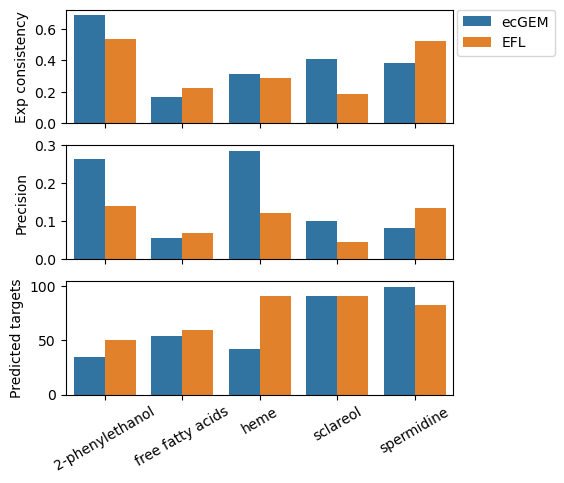

In [114]:
# compare the performance for different product
fig,axs=plt.subplots(3,1,figsize=(5,5))

# plot experiment constency
sns.barplot(x='product_name',y='l1_consistency',hue='model_type',data=slim_result_df,ax=axs[0])
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Exp consistency')
# set legend out 
axs[0].legend(title='Model type',bbox_to_anchor=(1.01, 1), borderaxespad=0.)

# plot experiment accuracy
sns.barplot(x='product_name',y='l1_precision',hue='model_type',data=slim_result_df,ax=axs[1],legend=False)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision')


# plot average distance
sns.barplot(x='product_name',y='l1_predict_num',hue='model_type',data=slim_result_df,ax=axs[2],legend=False)
axs[2].set_xlabel('')
axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=30)
axs[2].set_ylabel('Predicted targets')

# rename legend label
handles, labels = axs[0].get_legend_handles_labels()
label_map={'ecGEM':'ecGEM','etfl':'EFL'}
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.
)
# # plot average connectivity
# sns.barplot(ax=axs[3],x='product_name',y='l1_connectivity_score',hue='model_type',data=slim_result_df,legend=False)
# axs[3].set_xlabel('')
# # rotate x tick
# axs[3].set_xticklabels(axs[3].get_xticklabels(), rotation=30)
# axs[3].set_ylabel('Ave connectivity')
# set title
# fig.suptitle('Evaluation of ecGEM and EFL')
plt.show()

#### Compare prediction result in different level

In [ ]:
slim_result_df
df_result=pd.DataFrame(columns=['model_type','product_name','level','consistency','precision','predict_num','average_distance','connectivity_score'])
for index,row in slim_result_df.iterrows():
    model_type=row['model_type']
    product_name=row['product_name']
    prefixList=['l1','l2','l3','fcc']
    for prefix in prefixList:
        columns=[item for item in row.keys() if item.startswith(prefix)]
        values=row[columns].values.tolist()
        values=[model_type,product_name,prefix]+values
        df_result=pd.concat([df_result,pd.DataFrame([values],columns=df_result.columns)],ignore_index=True)

# save result
df_result.to_csv(r'analysis_code/results/ecGEM_vs_EFL_result.csv',index=False)

df_result.head()


C:\Users\wangh\AppData\Local\Temp\ipykernel_19496\3035199495.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[3].set_xticklabels(['ecGEM','EFL'])


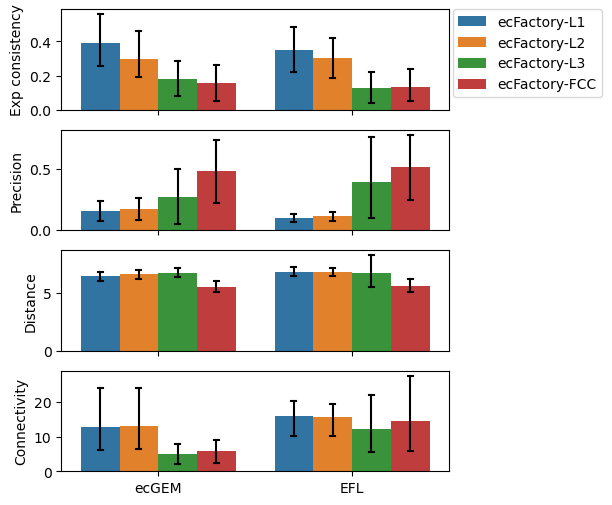

In [108]:
# plot the barplots for consistency, accuracy and predict num
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# slim_result_df=pd.read_csv(r'analysis_code/results/slim_result_df.csv')
# plot the barplots for consistency, accuracy and predict num and hue by model_type
fig,axs=plt.subplots(4,1,figsize=(5,6))

# plot experiment constency
sns.barplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Exp consistency')
# set legend outside and content as : l1:ecFactory-L1, l2: ecFactory-L2, l3: ecFactory-L3, fcc: ecFactory-FCC
label_map = {
    'l1': 'ecFactory-L1',
    'l2': 'ecFactory-L2',
    'l3': 'ecFactory-L3',
    'fcc': 'ecFactory-FCC'
}
handles, labels = axs[0].get_legend_handles_labels()
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.
)

# plot experiment accuracy
sns.barplot(x='model_type',y='precision',hue='level',data=df_result,ax=axs[1],legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision')


# plot average distance
sns.barplot(x='model_type',y='average_distance',hue='level',data=df_result,ax=axs[2],legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
axs[2].set_xlabel('')
axs[2].set_xticklabels([])
axs[2].set_ylabel('Distance')

# plot average connectivity
sns.barplot(ax=axs[3],x='model_type',y='connectivity_score',hue='level',data=df_result,legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
axs[3].set_xlabel('')
axs[3].set_xticklabels(['ecGEM','EFL'])
axs[3].set_ylabel('Connectivity')
# set title
# fig.suptitle('Evaluation of ecGEM and EFL')
plt.show()

#### Compare different positive targets from EFL and ecGEM model

In [18]:
# compare the predicted positive targets difference
ecFactory_positive_targets_by_level_dict={'l1':{'ecGEM':[],'etfl':[]},'l2':{'ecGEM':[],'etfl':[]},'l3':{'ecGEM':[],'etfl':[]}}
ecFactory_positive_targets_by_product_dict={}

for model_type,all_products_dict in full_results_dict.items():
    for product_name,all_levels_dict in all_products_dict.items():
        for level,all_targets_dict in all_levels_dict.items():
            if level in ecFactory_positive_targets_by_level_dict.keys():
                for target_type,target_type_dict in all_targets_dict.items():
                    if target_type in ['KO','KD','OE']:
                        targets_list=target_type_dict['hit']
                        targets_list=list(set(targets_list))

                        # add to ecFactory_positive_targets classify by products
                        if level=='l1':
                            if product_name not in ecFactory_positive_targets_by_product_dict.keys():
                                ecFactory_positive_targets_by_product_dict[product_name]={}
                            if model_type not in ecFactory_positive_targets_by_product_dict[product_name].keys():
                                ecFactory_positive_targets_by_product_dict[product_name][model_type]=[]
                            ecFactory_positive_targets_by_product_dict[product_name][model_type].extend(targets_list)
                        
                        # add to ecFactory positive targets classify by level
                        targets_list=[product_name+'_'+id for id in targets_list]
                        ecFactory_positive_targets_by_level_dict[level][model_type].extend(targets_list)
                ecFactory_positive_targets_by_level_dict[level][model_type]=list(set(ecFactory_positive_targets_by_level_dict[level][model_type]))

# save result
import json
with open(r'analysis_code\results\ecGEM_vs_EFL\ecFactory_positive_targets_by_level_dict.json','w') as f:
    json.dump(ecFactory_positive_targets_by_level_dict,f)

for level, result_dict in ecFactory_positive_targets_by_level_dict.items():
    print(level)
    ecgem_targets=set(result_dict['ecGEM'])
    etfl_targets=set(result_dict['etfl'])
    print('ecGEM specific targets:',ecgem_targets-etfl_targets)
    print('EFL specific targets:',etfl_targets-ecgem_targets)


for product_name, result_dict in ecFactory_positive_targets_by_product_dict.items():
    print(product_name)
    ecgem_targets=set(result_dict['ecGEM'])
    etfl_targets=set(result_dict['etfl'])
    print('ecGEM specific targets:',ecgem_targets-etfl_targets)
    print('EFL specific targets:',etfl_targets-ecgem_targets)
    print('ecGEM&EFL common targets:',ecgem_targets.intersection(etfl_targets))


l1
ecGEM specific targets: {'sclareol_YHR183W', 'heme_YNR043W', 'ffa_YNL241C', 'sclareol_YMR241W', 'sclareol_YGL080W', 'ffa_YHR183W', 'sclareol_YGR243W', '2-phenylethanol_YPR074C', 'spermidine_YLR146C', 'sclareol_YNL241C', '2-phenylethanol_YNL241C'}
EFL specific targets: {'ffa_YMR241W', 'spermidine_YJR148W', 'spermidine_YOL061W', 'spermidine_YML022W', 'ffa_YLR354C', 'ffa_YLR174W', 'spermidine_YOR375C'}
l2
ecGEM specific targets: {'sclareol_YHR183W', 'heme_YNR043W', 'ffa_YNL241C', 'ffa_YHR183W', '2-phenylethanol_YPR074C', 'spermidine_YLR146C', 'sclareol_YNL241C', '2-phenylethanol_YNL241C'}
EFL specific targets: {'ffa_YMR241W', 'spermidine_YJR148W', 'spermidine_YDR502C', 'spermidine_YOL061W', 'spermidine_YPR021C', 'ffa_YLR354C', 'ffa_YLR174W', 'spermidine_YOR130C', 'spermidine_YOR375C'}
l3
ecGEM specific targets: {'heme_YNR043W', 'spermidine_YPR069C', '2-phenylethanol_YPR060C', 'spermidine_YLR017W', 'spermidine_YOL052C', 'spermidine_YKL184W', 'ffa_YNR016C'}
EFL specific targets: {'spermi

d:\softwares\programming\anoconda\envs\data\Lib\site-packages\venn\_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((
d:\softwares\programming\anoconda\envs\data\Lib\site-packages\venn\_backwards_compatibility.py:30: UserWarning: `venn2()` is retained for backwards compatibility; use `venn()` instead
  warn((


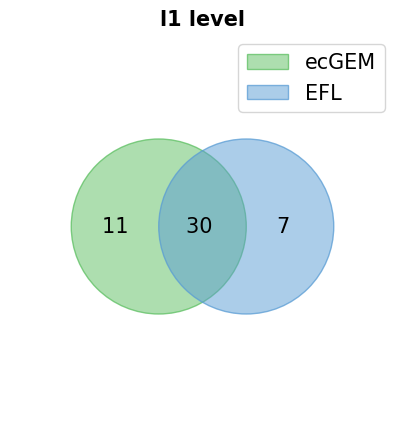

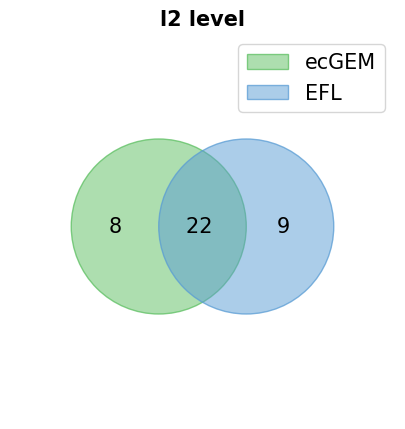

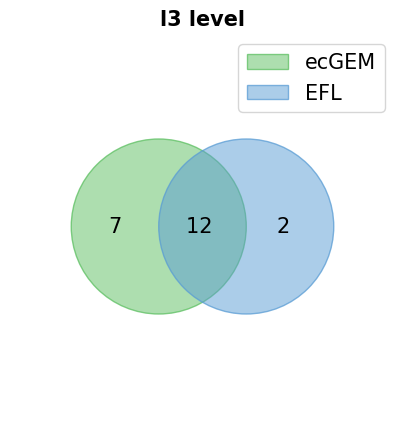

In [17]:
# plot ven
import venn

# fig,axs=plt.subplots(3,1,figsize=(5,15))
for level, result_dict in ecFactory_positive_targets_by_level_dict.items():
    predicted_targets=[set(targets) for model_type,targets in result_dict.items()]
    names=['ecGEM','EFL']
    
    labels = venn.get_labels(predicted_targets, fill=['number', 
                                                                # 'logic',#开启每个组分代码
                                                                # 'percent'#每个组分的百分比
                                                               ],)
    venn.venn2(labels, names=names,figsize=(6,5),fontsize=15)
    # add title
    plt.title(f'{level} level',fontsize=15,fontweight='bold')
    plt.show()

### Chek how many non-metabolic genes predicted by EFL model

In [14]:
# check EFL predict targets that not exist in yeastGEM
import cobra
met_geneList=[gene.id for gene in cobra.io.read_sbml_model(r'data\yeast-GEM.xml').genes]
for file in os.listdir(r'analysis_code\results\ecGEM_vs_efl'):
    if 'etfl' not in file:
        continue
    if file.endswith('.xlsx'):
        model_type=file.split('_')[0]
        product_name=file.split('_')[1]
        
        # load predicted result
        df=pd.read_excel(f'analysis_code/results/ecGEM_vs_efl/{file}',sheet_name='geneTable',index_col=0)

        predicted_targetList=df.index.tolist()
        specific_targets=list(set(predicted_targetList)-set(met_geneList))
        # specific_targets=[product_name+'_'+id for id in specific_targets]

        print(product_name,specific_targets)

2-phenylethanol ['YDL140C', 'YOR151C', 'YIL021W', 'YBR154C', 'YPR187W']
free fatty acids []
heme ['YMR228W', 'YFL036W']
sclareol ['YNL315C', 'SsTPS', 'YJL180C', 'FRTT', 'YLR393W', 'SsLPPS']
spermidine []


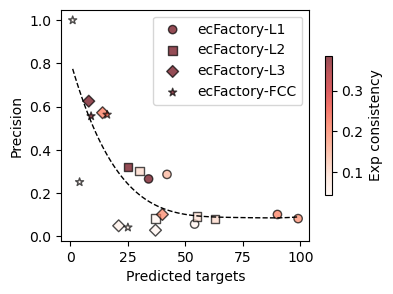

In [173]:
df_ecgem=df_result[df_result['model_type']=='ecGEM']
# plot the scatter plot
colore_consistency=df_result['consistency'].tolist()
y_precision=df_result['precision'].tolist()
size_num=df_result['predict_num'].tolist()
color_level=df_result['level'].tolist()

# color_map={'l1':'red','l2':'blue','l3':'green','fcc':'yellow'}
marker_map = {'l1': 'o', 'l2': 's', 'l3': 'D', 'fcc': '*'}  # 圆形/方形/菱形

marker_list=[marker_map[i] for i in color_level]
fig, ax = plt.subplots(figsize=(4,3))
for level,marker in marker_map.items():
    df_selected=df_ecgem[df_ecgem['level']==level]
    sc = ax.scatter(df_selected['predict_num'], df_selected['precision'], c=df_selected['consistency'],marker=marker, alpha=0.7, edgecolors='k',cmap='Reds',label=level)

# 拟合线（线性回归）
coef = np.polyfit(df_ecgem['predict_num'].values.astype(float), df_ecgem['precision'].values.astype(float), deg=4)   # 一次多项式
poly_fn = np.poly1d(coef)        # 生成拟合函数

x_line = np.linspace(min(df_ecgem['predict_num']), max(df_ecgem['predict_num']), 100)
y_line = poly_fn(x_line)
ax.plot(x_line, y_line, color="black", linewidth=1,linestyle='--')

# set colore bar
cbar = plt.colorbar(sc, ax=ax,shrink=0.6,location='right')
cbar.set_label("Exp consistency")

# set marker category
ax.legend(title="Category")
label_map = {
    'l1': 'ecFactory-L1',
    'l2': 'ecFactory-L2',
    'l3': 'ecFactory-L3',
    'fcc': 'ecFactory-FCC'
}
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_map.get(l, l) for l in labels]
ax.legend(
    handles,
    new_labels,
    # title='Level',
    # bbox_to_anchor=(1.01, 1),
    # borderaxespad=0.
)


# set x, y label
ax.set_xlabel('Predicted targets')
ax.set_ylabel('Precision')
plt.show()